29.999999999999996
29.99923326831964


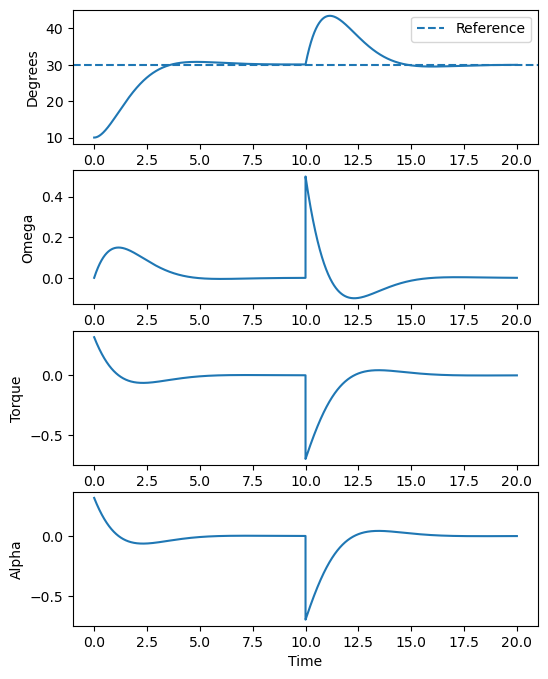

In [11]:
import numpy as np
import matplotlib.pyplot as plt

taumax = 10
theta_cur = np.deg2rad(10)
I = 1
steps = 20000

theta_ref = np.deg2rad(30)
kp = 0.913
ki = 0.004
kd = 1.4
dt = 0.001

err_prev = theta_ref - theta_cur

integ_term = 0
w_old = 0
theta_values = []
w_values = []
alpha_values = []
tau_values = []
tol_time = []

time = np.arange(steps)*dt

for i in range(steps): 
    if i == int(10/dt):
        w_old += 0.5
    theta_err = theta_ref - theta_cur
    
    prop = kp * (theta_err)
    deriv = -kd * w_old
    
    integ_term += theta_err * dt
    integ = ki * (integ_term)
    
    tau = prop + deriv + integ
    tau = np.clip(tau, -taumax, taumax)
    
    alpha = tau/I
    
    w_new = w_old + alpha*dt
    theta_cur += w_new*dt
    
    err_prev = theta_err
    
    theta_values.append(theta_cur)
    w_values.append(w_new)
    alpha_values.append(alpha)
    tau_values.append(tau)
    
    w_old = w_new

print(np.rad2deg(theta_ref))
print(np.rad2deg(theta_cur))
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4,1, figsize=(6, 8))

ax1.plot(time, np.rad2deg(theta_values))
ax1.set_xlabel("Time")
ax1.set_ylabel("Degrees")
ax1.axhline(np.rad2deg(theta_ref), linestyle="--", label="Reference")
ax1.legend()

ax2.plot(time, w_values)
ax2.set_xlabel("Time")
ax2.set_ylabel("Omega")

ax3.plot(time, tau_values)
ax3.set_xlabel("Time")
ax3.set_ylabel("Torque")

ax4.plot(time, alpha_values)
ax4.set_xlabel("Time")
ax4.set_ylabel("Alpha")

plt.show()

Max Overshoot: 0.512 degrees
Overshoot Percentage:  2.559603402524749 %
Reference Angle:  29.999999999999996 °
Final Angle:  30.069710233897787 °
Steady State Error:  -0.2771788315515123 °
Peak Torque:  0.26180113312840136
Settling Time:  7.722 s


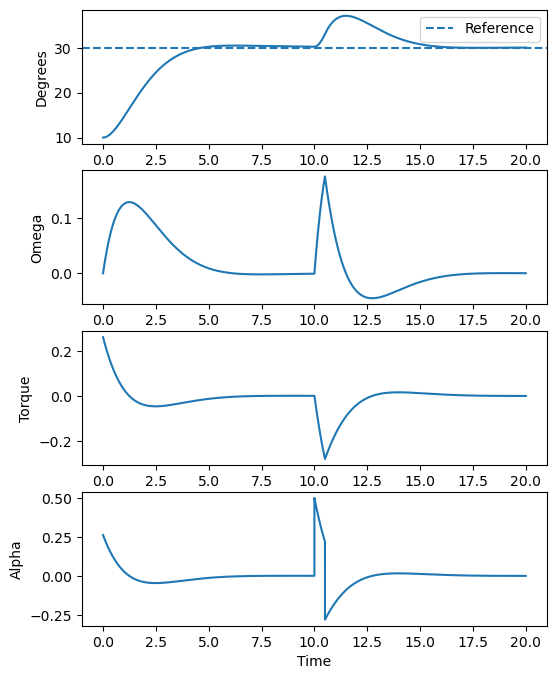

In [27]:
import numpy as np
import matplotlib.pyplot as plt

taumax = 10
theta_cur = np.deg2rad(10)
I = 1
steps = 20000

theta_ref = np.deg2rad(30)
kp = 0.75
ki = 0.005
kd = 1.4
dt = 0.001

err_prev = theta_ref - theta_cur

integ_term = 0
w_old = 0
theta_values = []
w_values = []
alpha_values = []
tau_values = []

time = np.arange(steps)*dt

for i in range(steps): 
    if 10 <= i*dt < 10.5:
        tau_disturbance = 0.5
    else:
        tau_disturbance = 0
    
    theta_err = theta_ref - theta_cur
    
    prop = kp * (theta_err)
    deriv = -kd * w_old
    
    integ_term += theta_err * dt
    integ = ki * (integ_term)
    
    tau = prop + deriv + integ
    tau = np.clip(tau, -taumax, taumax)
        
    alpha = (tau + tau_disturbance) / I
    
    w_new = w_old + alpha*dt
    theta_cur += w_new*dt
    
    err_prev = theta_err
    
    theta_values.append(theta_cur)
    w_values.append(w_new)
    alpha_values.append(alpha)
    tau_values.append(tau)
            
    w_old = w_new

#analysis section --------------------------
#lets change all lists to arrays

theta_values = np.array(theta_values)
w_values = np.array(w_values)
tau_values = np.array(tau_values)
alpha_values = np.array(alpha_values)
pre_disturbance = time < 10

theta_pre = theta_values[pre_disturbance] #radians
tau_pre = tau_values[pre_disturbance]
theta_max_pre = np.max(theta_pre) #radians

initial_angle = np.deg2rad(10)
tolerance = 0.02 * abs(theta_ref - initial_angle)
error_tol = np.abs(theta_pre - theta_ref)
time_pre = time[pre_disturbance]

outside_band = np.where(error_tol > tolerance)[0]
if len(outside_band) == 0:
    settling_time = 0
elif outside_band[-1] == len(time_pre) - 1:
    settling_time = np.nan
else:
    settling_time = time_pre[outside_band[-1] + 1]

steady_state_angle = np.mean(theta_pre[-1000:])
ess = theta_ref - steady_state_angle 
ess_deg = np.rad2deg(ess) #deg

step_size = np.rad2deg(abs(theta_ref - initial_angle))
Mp_pre = max(0,np.rad2deg(theta_max_pre - theta_ref)) #deg, also max(0,---) cuz no -ve
Mp_pre_per = (Mp_pre * 100)/step_size #deg
max_torq = np.max(np.abs(tau_pre)) #pre-disturbance

print(f"Max Overshoot: {Mp_pre:.3f} degrees")
print("Overshoot Percentage: ", Mp_pre_per, "%")
print("Reference Angle: ", np.rad2deg(theta_ref), "°")
print("Final Angle: ", np.rad2deg(theta_cur), "°")
print("Steady State Error: ", ess_deg, "°")
print("Peak Torque: ", max_torq)
print("Settling Time: ", settling_time, "s")

#Plotting ------------------------
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4,1, figsize=(6, 8))
ax1.plot(time, np.rad2deg(theta_values))
ax1.set_xlabel("Time")
ax1.set_ylabel("Degrees")
ax1.axhline(np.rad2deg(theta_ref), linestyle="--", label="Reference")
ax1.legend()

ax2.plot(time, w_values)
ax2.set_xlabel("Time")
ax2.set_ylabel("Omega")

ax3.plot(time, tau_values)
ax3.set_xlabel("Time")
ax3.set_ylabel("Torque")

ax4.plot(time, alpha_values)
ax4.set_xlabel("Time")
ax4.set_ylabel("Alpha")

plt.show()